In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Set plot style
sns.set(style='whitegrid')

In [2]:
# Sample dataset
data = {
    'age': np.random.randint(18, 70, 1000),
    'gender': np.random.choice(['Male', 'Female'], 1000),
    'income': np.random.randint(20000, 100000, 1000),
    'purchased': np.random.choice([0, 1], 1000)
}
df = pd.DataFrame(data)
df.head()

,age,gender,income,purchased
0,45,Female,39082,0
1,56,Male,85065,1
2,37,Male,41691,1
3,26,Male,39788,1
4,28,Male,50770,0


In [3]:
# Encode categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Split the dataset into features and target variable
X = df.drop('purchased', axis=1)
y = df['purchased']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# Initialize the decision tree classifier
classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
# Make predictions
y_pred = classifier.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.48333333333333334
Confusion Matrix:
 [[69 83]
 [72 76]]
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.45      0.47       152
           1       0.48      0.51      0.50       148

    accuracy                           0.48       300
   macro avg       0.48      0.48      0.48       300
weighted avg       0.48      0.48      0.48       300



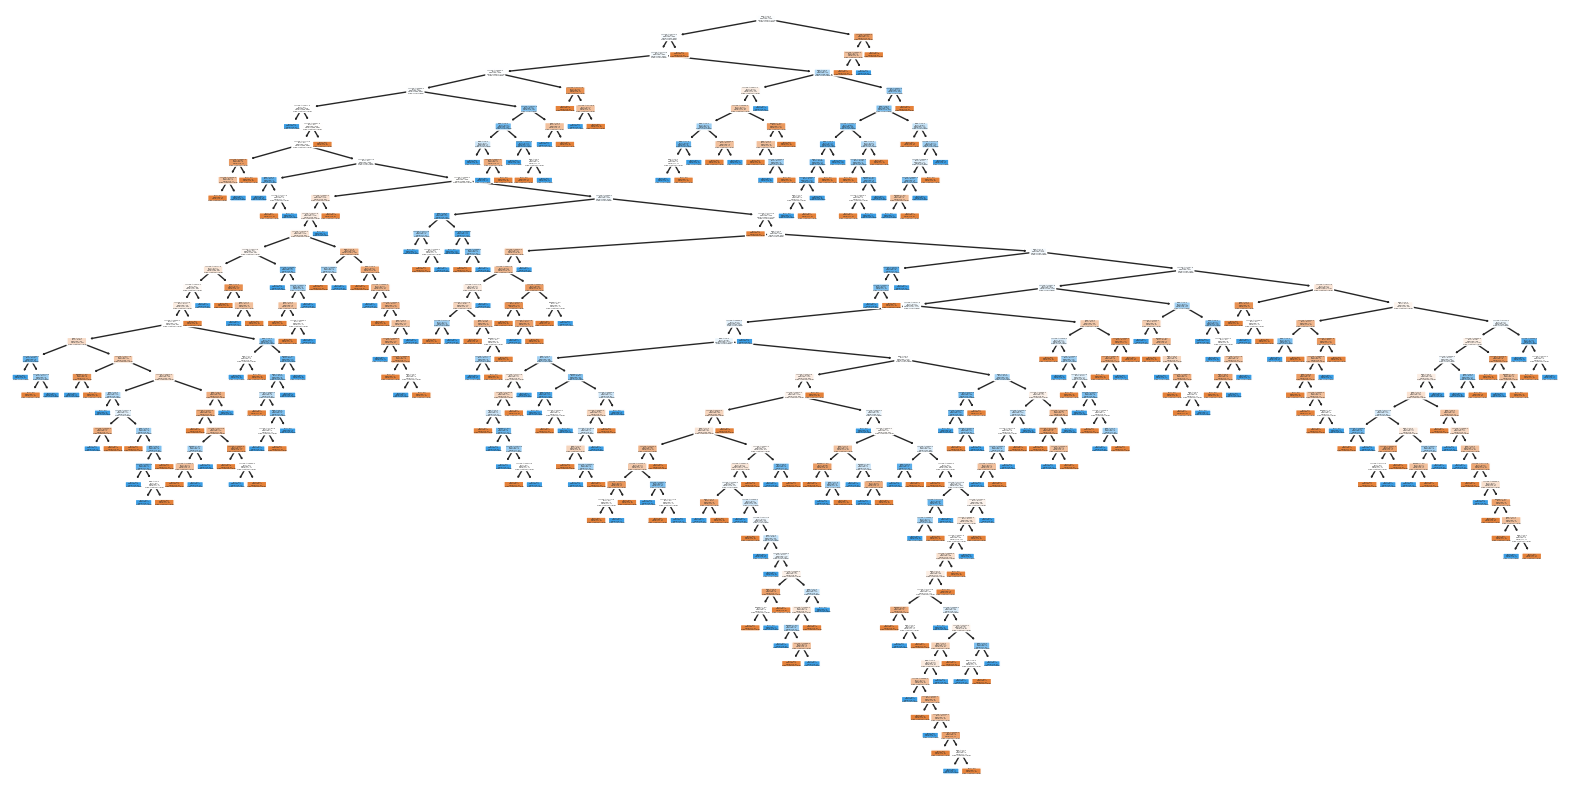

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(classifier, feature_names=X.columns, class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True)
plt.show()